# 🎙️ Advanced Subtitle Pipeline: RoFormer Vocal Isolation + Whisper Transcription

## 📌 Project Overview
Transcribing audio with heavy background noise, music, or sound effects often leads to hallucinations or inaccuracies in standard Speech-to-Text models. This pipeline solves that issue by introducing an audio pre-processing step using **RoFormer**, a State-of-the-Art (SOTA) model for stem separation, to isolate human vocals perfectly before feeding them into **OpenAI's Whisper (Large-v3)**.

**Architecture Flow:**
`Raw Media (Audio/Video)` ➔ `RoFormer (BGM Removal)` ➔ `Clean Vocal Track` ➔ `Whisper (Transcription)` ➔ `.SRT Subtitle File`

This approach guarantees significantly lower Word Error Rates (WER) and eliminates noise-induced AI hallucinations, making it ideal for Hollywood movies, noisy English podcasts, or gaming streams.

In [1]:
# Install required dependencies
# audio-separator handles the RoFormer model downloading and inference automatically
!pip install -q openai-whisper
!pip install -q gdown
!pip install -q "audio-separator[gpu]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 54.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.8/917.8 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━

## ⚙️ 1. Setup & Initialization
Importing necessary libraries and setting up a logging mechanism. Professional pipelines rely on structured logging rather than simple `print` statements for better debugging and traceability.

## 🧠 Algorithm Deep-Dive: Why BS-RoFormer?

Before passing audio to our transcription model, we must isolate the human voice from background music (BGM), sound effects, and environmental noise. Standard noise-reduction techniques (like spectral gating) often degrade vocal quality. 

To solve this, we utilize **BS-RoFormer (Band-Split Rotary Position Embedding Transformer)**, a state-of-the-art model for Music Source Separation (MSS).

**How it works:**
1. **Band-Splitting:** The model splits the audio's spectrogram into multiple frequency bands, recognizing that vocals and instruments exhibit different patterns across different frequencies.
2. **Rotary Position Embeddings (RoPE):** Unlike standard Transformers that use absolute positional embeddings, RoFormer uses RoPE. This allows the model to better understand the relative distance between audio frames over time, capturing the temporal flow of music and vocals with extreme precision.
3. **Masking & Extraction:** The Transformer predicts a complex mask that isolates the vocal frequencies, successfully separating the human voice without leaving robotic audio artifacts.

In [2]:
import os
import zipfile
import logging
import subprocess
from pathlib import Path
from typing import List, Optional, Dict, Any

import whisper
import gdown

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

## 🗣️ Algorithm Deep-Dive: OpenAI Whisper (Large-v3)

With a perfectly isolated vocal track, we can achieve maximum accuracy using **OpenAI Whisper**, a robust Automatic Speech Recognition (ASR) system. 

Whisper is built on a massive **Encoder-Decoder Transformer** architecture trained on 5 million hours of multilingual data. 

**How it works in our pipeline:**
1. **Log-Mel Spectrogram:** The clean, isolated vocal audio is converted into a log-Mel spectrogram (a visual representation of audio frequencies over time).
2. **Encoder:** The Transformer's encoder processes this spectrogram to extract high-level feature representations of the speech.
3. **Decoder:** The decoder relies on cross-attention mechanisms to map these audio features into text tokens (in this case, English text). 

**Why the RoFormer Pre-processing is Crucial:** Whisper operates autoregressively (predicting the next word based on previous words). If it hears loud background music, the encoder generates noisy features, causing the decoder to "hallucinate" repetitive or non-existent words. By feeding it purely isolated vocals from RoFormer, we completely eliminate this hallucination vector, resulting in near-perfect Word Error Rates (WER).

## 🏗️ 2. Core Pipeline Architecture (OOP Approach)
We encapsulate the entire workflow within the `SubtitlePipeline` class. This Object-Oriented approach ensures the code is modular, scalable, and easy to integrate into larger software systems.

**Key Features:**
* **Dynamic Path Handling:** Utilizes `pathlib` for OS-agnostic path management.
* **Robust Error Handling:** File-specific `try-except` blocks prevent the entire pipeline from crashing due to a single corrupted media file.
* **Type Hinting:** Enhances code readability and maintainability.

In [3]:
class SubtitlePipeline:
    def __init__(self, workspace_dir: str = "/kaggle/working", whisper_model: str = "large-v3"):
        self.workspace = Path(workspace_dir)
        self.output_dir = self.workspace / "output"
        self.vocal_dir = self.workspace / "vocals"
        self.extract_dir = self.workspace / "extracted"
        
        self._create_directories()
        
        logger.info(f"Loading Whisper model: '{whisper_model}'...")
        self.model = whisper.load_model(whisper_model)
        
        # BS-RoFormer is currently one of the highest SDR (Signal-to-Distortion Ratio) models for vocals
        self.roformer_model = "model_bs_roformer_ep_317_sdr_12.9755.ckpt"

    def _create_directories(self) -> None:
        """Create necessary working directories."""
        for directory in [self.output_dir, self.vocal_dir, self.extract_dir]:
            directory.mkdir(parents=True, exist_ok=True)

    def download_and_extract(self, gdrive_id: str) -> None:
        """Download dataset from Google Drive and extract it."""
        zip_path = self.workspace / "dataset.zip"
        url = f"https://drive.google.com/uc?id={gdrive_id}"
        
        logger.info("Downloading dataset from Google Drive...")
        gdown.download(url, str(zip_path), quiet=False)
        
        logger.info("Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.extract_dir)
        logger.info("Extraction completed.")

    def isolate_vocals(self, audio_path: Path) -> Path:
        """Isolate vocals from the media using RoFormer."""
        logger.info(f"Isolating vocals for: {audio_path.name}")
        
        command = [
            "audio-separator", str(audio_path),
            "--model_filename", self.roformer_model,
            "--output_dir", str(self.vocal_dir),
            "--single_stem", "Vocals"
        ]
        
        # Run CLI command silently
        subprocess.run(command, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
        # Locate the generated vocal track
        vocal_files = list(self.vocal_dir.glob(f"*{audio_path.stem}*(Vocals)*.*"))
        if not vocal_files:
            raise FileNotFoundError(f"Failed to extract vocals for {audio_path.name}")
            
        return vocal_files[0]

    def _format_timestamp(self, seconds: float) -> str:
        """Convert seconds into SRT timestamp format (HH:MM:SS,MMM)."""
        hours = int(seconds // 3600)
        minutes = int((seconds % 3600) // 60)
        secs = int(seconds % 60)
        millis = int((seconds % 1) * 1000)
        return f"{hours:02d}:{minutes:02d}:{secs:02d},{millis:03d}"

    def create_srt(self, segments: List[Dict[str, Any]], original_name: str) -> Path:
        """Generate an .srt file from Whisper's transcription segments."""
        srt_path = self.output_dir / f"{original_name}.srt"
        
        with open(srt_path, 'w', encoding='utf-8') as f:
            for i, segment in enumerate(segments, start=1):
                start_time = self._format_timestamp(segment['start'])
                end_time = self._format_timestamp(segment['end'])
                text = segment['text'].strip()
                
                f.write(f"{i}\n{start_time} --> {end_time}\n{text}\n\n")
                
        return srt_path

    def transcribe(self, vocal_path: Path, original_audio_path: Path, language: str = 'en') -> Path:
        """Transcribe the isolated vocal track using Whisper."""
        logger.info(f"Transcribing: {vocal_path.name} (Target Language: {language})")
        
        result = self.model.transcribe(
            str(vocal_path),
            language=language,
            task='transcribe',
            verbose=False
        )
        
        srt_path = self.create_srt(result['segments'], original_audio_path.stem)
        logger.info(f"Subtitle generated successfully: {srt_path.name}")
        return srt_path

    def package_results(self) -> Path:
        """Package all generated SRT files into a single ZIP archive."""
        output_zip = self.workspace / "subtitles_result.zip"
        srt_files = list(self.output_dir.glob("*.srt"))
        
        with zipfile.ZipFile(output_zip, 'w') as zipf:
            for file in srt_files:
                zipf.write(file, file.name)
                
        logger.info(f"All subtitles packaged at: {output_zip}")
        return output_zip

    def run_pipeline(self, gdrive_id: Optional[str] = None, language: str = 'ja') -> None:
        """Execute the end-to-end pipeline."""
        try:
            if gdrive_id:
                self.download_and_extract(gdrive_id)
                
            audio_files = [
                f for f in self.extract_dir.rglob("*") 
                if f.suffix.lower() in ['.mp3', '.wav', '.m4a', '.mp4', '.mkv', '.flac']
            ]
            
            if not audio_files:
                logger.warning("No audio or video files found for processing.")
                return

            logger.info(f"Starting processing for {len(audio_files)} files...")
            
            for audio_file in audio_files:
                try:
                    vocal_path = self.isolate_vocals(audio_file)
                    self.transcribe(vocal_path, audio_file, language=language)
                except Exception as e:
                    logger.error(f"Failed to process {audio_file.name}: {e}")
                    
            self.package_results()
            logger.info("Pipeline executed successfully! 🚀")
            
        except Exception as e:
            logger.critical(f"Pipeline terminated due to critical error: {e}")

## 🚀 3. Execution
Run the pipeline by providing the Google Drive ID containing the raw media files. The output will be a downloadable ZIP file containing all the generated `.srt` subtitles.

In [4]:
# Replace with your actual Google Drive File ID
GDRIVE_ID = "1sZIZZmUAClifmJNbQ0iNhvPJeMcHhmSF"

if __name__ == "__main__":
    # Initialize and run the pipeline
    # Note: Change language='en' for English, etc.
    pipeline = SubtitlePipeline()
    pipeline.run_pipeline(gdrive_id=GDRIVE_ID, language='en')

2026-04-10 23:39:14,616 [INFO] Loading Whisper model: 'large-v3'...
100%|██████████████████████████████████████| 2.88G/2.88G [00:17<00:00, 174MiB/s]
2026-04-10 23:40:02,497 [INFO] Downloading dataset from Google Drive...
Downloading...
From: https://drive.google.com/uc?id=1sZIZZmUAClifmJNbQ0iNhvPJeMcHhmSF
To: /kaggle/working/dataset.zip
100%|██████████| 7.06M/7.06M [00:00<00:00, 10.5MB/s]
2026-04-10 23:40:04,122 [INFO] Extracting files...
2026-04-10 23:40:04,169 [INFO] Extraction completed.
2026-04-10 23:40:04,171 [INFO] Starting processing for 1 files...
2026-04-10 23:40:04,171 [INFO] Isolating vocals for: output.mp3
2026-04-10 23:43:44,892 [INFO] Transcribing: output_(Vocals)_model_bs_roformer_ep_317_sdr_12.flac (Target Language: en)
100%|██████████| 44285/44285 [01:59<00:00, 369.16frames/s]
2026-04-10 23:45:45,812 [INFO] Subtitle generated successfully: output.srt
2026-04-10 23:45:45,814 [INFO] All subtitles packaged at: /kaggle/working/subtitles_result.zip
2026-04-10 23:45:45,814 [

## 📊 4. Visual Evidence: Original vs. Isolated Vocals
To truly appreciate the power of the RoFormer model, let's visualize the audio waveforms. 

The plot below compares the raw audio (which includes dense background music and noise) against the purely isolated vocal track. Notice how the chaotic frequencies in the original track are stripped away, leaving only the clean speech patterns for Whisper to transcribe accurately.

2026-04-10 23:51:21,338 [INFO] Loading audio files for visualization (this might take a moment)...
/tmp/ipykernel_55/2839887142.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y_orig, sr_orig = librosa.load(original_path, duration=30.0)
[src/libmpg123/parse.c:skip_junk():1260] error: Giving up searching valid MPEG header after 65536 bytes of junk.
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
2026-04-10 23:51:23,402 [INFO] Gambar berhasil disimpan di: /kaggle/working/waveform_comparison.png


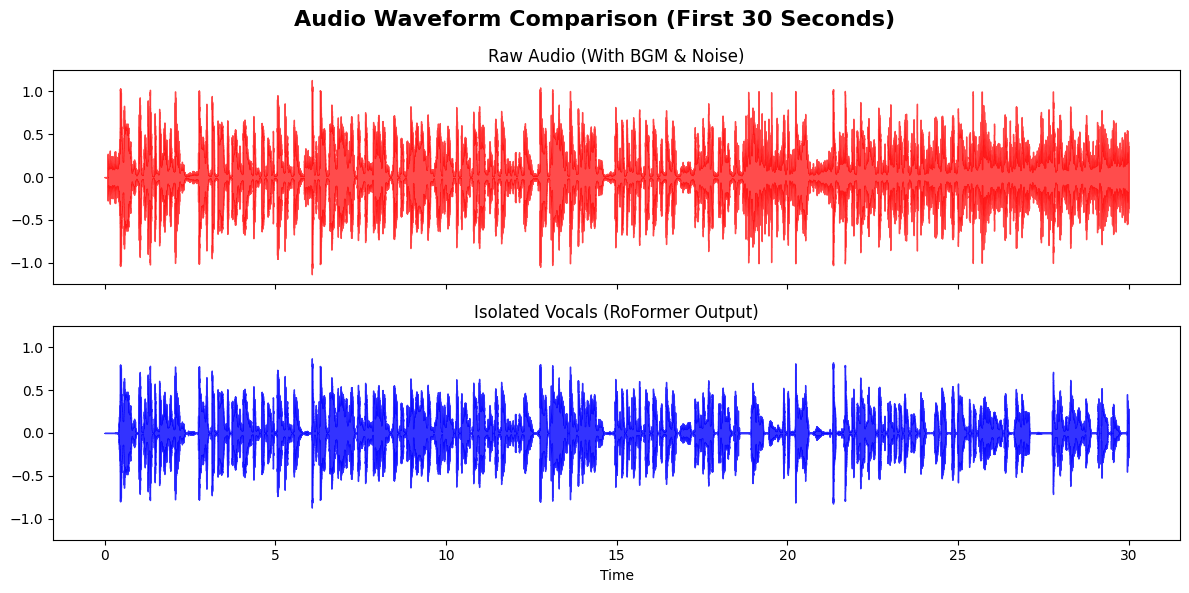

2026-04-10 23:51:23,909 [INFO] GPU VRAM cleared.


In [8]:
# Install librosa for audio visualization
!pip install -q librosa matplotlib

import librosa
import librosa.display
import matplotlib.pyplot as plt
import gc
import torch

def plot_audio_comparison(original_path: str, vocal_path: str):
    """Visualizes the waveform of original audio vs isolated vocals."""
    logger.info("Loading audio files for visualization (this might take a moment)...")
    
    # Load audio (limiting to first 30 seconds to save RAM)
    y_orig, sr_orig = librosa.load(original_path, duration=30.0)
    y_vocal, sr_vocal = librosa.load(vocal_path, duration=30.0)
    
    # Plotting
    fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(12, 6))
    fig.suptitle('Audio Waveform Comparison (First 30 Seconds)', fontsize=16, fontweight='bold')
    
    # Original Audio
    librosa.display.waveshow(y_orig, sr=sr_orig, ax=ax[0], color='red', alpha=0.7)
    ax[0].set(title='Raw Audio (With BGM & Noise)')
    ax[0].label_outer()
    
    # Isolated Vocals
    librosa.display.waveshow(y_vocal, sr=sr_vocal, ax=ax[1], color='blue', alpha=0.8)
    ax[1].set(title='Isolated Vocals (RoFormer Output)')
    
    plt.tight_layout()
    save_path = "/kaggle/working/waveform_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight') # dpi=300 agar gambarnya HD/Tidak Pecah
    logger.info(f"Gambar berhasil disimpan di: {save_path}")
    plt.show()

    # --- GPU MEMORY MANAGEMENT ---
    # Clear RAM and VRAM after heavy processing
    del y_orig, y_vocal
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        logger.info("GPU VRAM cleared.")

SAMPLE_ORIGINAL = "/kaggle/working/extracted/output.mp3"
SAMPLE_VOCAL = "/kaggle/working/vocals/output_(Vocals)_model_bs_roformer_ep_317_sdr_12.flac"

plot_audio_comparison(SAMPLE_ORIGINAL, SAMPLE_VOCAL)